# Example of usage of **SimCaNet**

In [1]:
import SimCaNet as simulator
import time
import matplotlib.pyplot as plt

# 1. Import or build a new graph

Elapsed Time: 3.6751227378845215


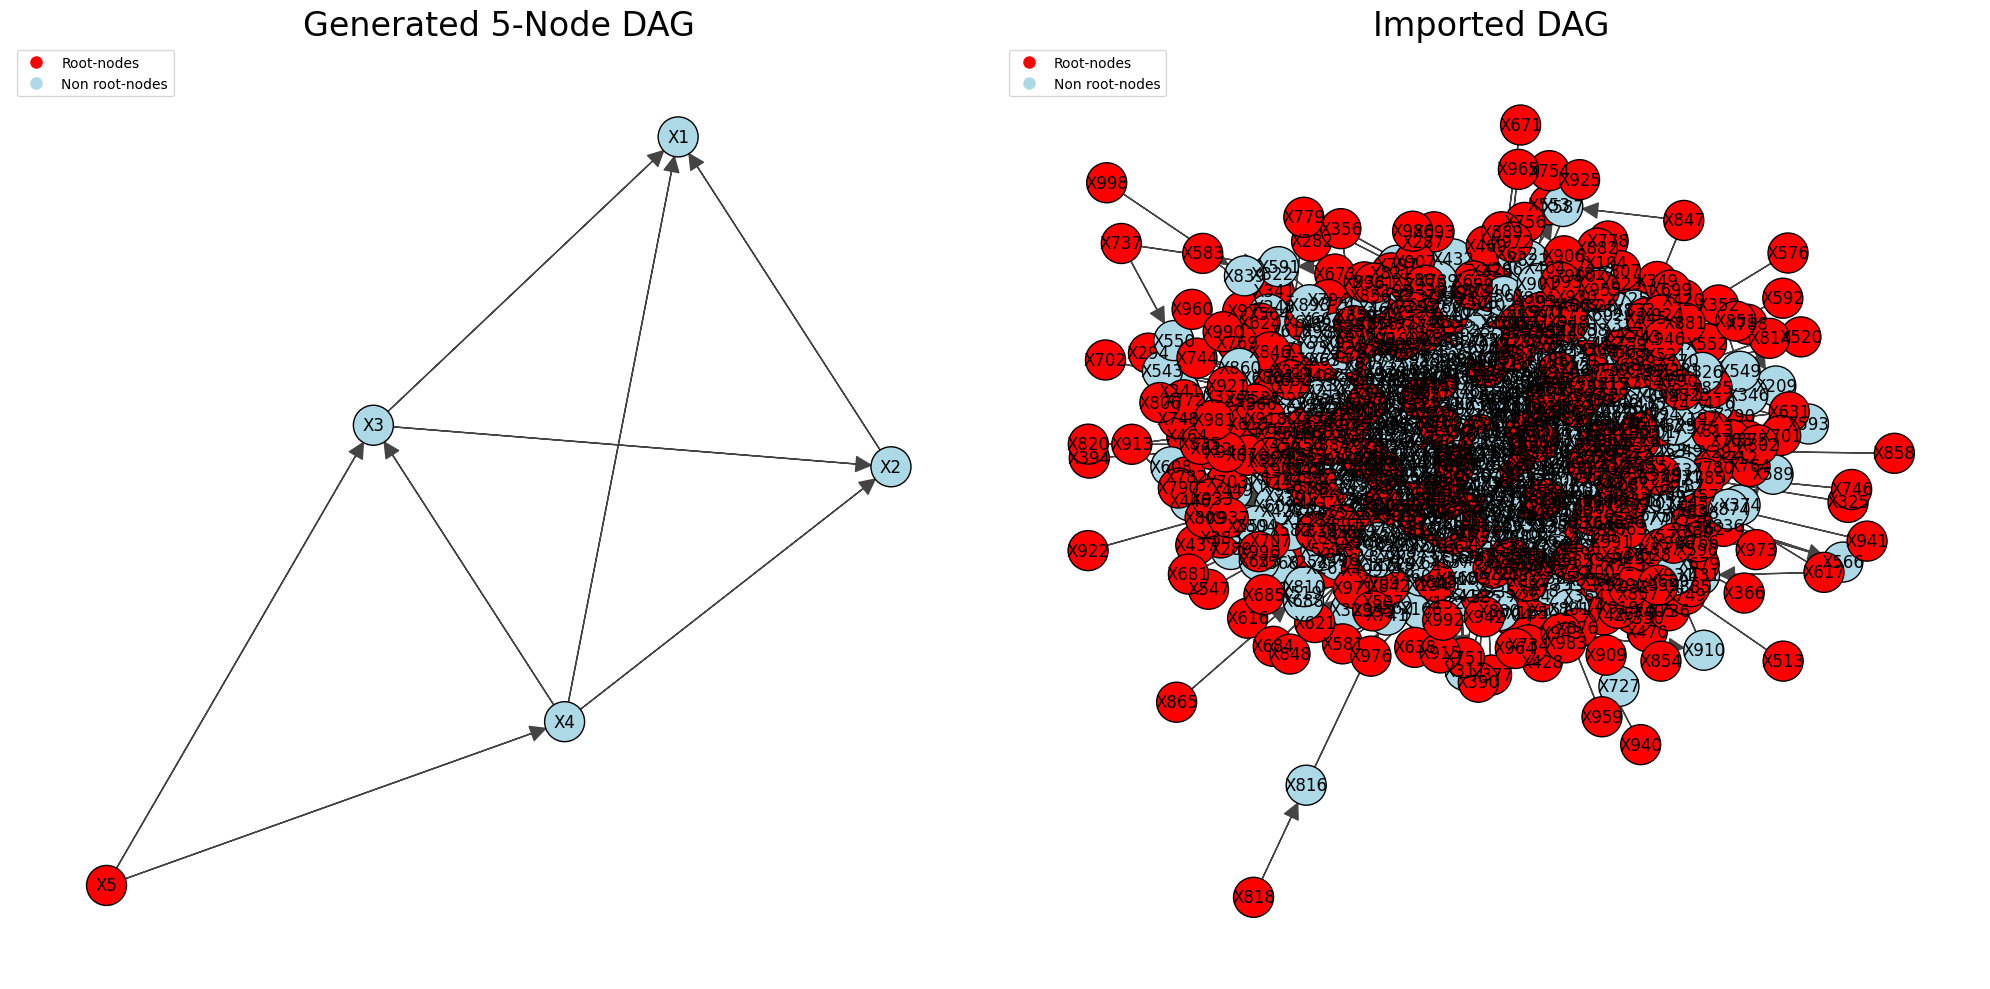

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

t1 = time.time()
# Generate a random 5-node DAG
g_generated, nodes_generated = simulator.graph_generation_or_importation(number_of_nodes=5,degree_mean=2,execute_graph=True,file_name=None,ax=ax1)
ax1.set_title("Generated 5-Node DAG", fontsize=24)

# Import a pre-defined 1000-node DAG
g, nodes = simulator.graph_generation_or_importation(number_of_nodes=50,degree_mean=2,execute_graph=False,file_name='barabasi_1000_nodes.pkl',ax=ax2)
ax2.set_title("Imported DAG", fontsize=24)

t2=time.time()
print(f'Elapsed Time: {t2-t1}')

plt.tight_layout()
plt.show()

# 2. Analyzing the causal graph (1000-node network)

In [3]:
t3 = time.time()
simulator.graph_analysis(g_generated)
t4= time.time() 
print(f'Elapsed Time: {t4-t3}')

SOME METRICS!
Number of Nodes: 1000
Number of Edges: 3880
Number of Root nodes: 333
Number of Non-Root nodes: 667
Number of open triplets: 56118
Number of closed triplets: 570
Graph Density: 0.0039
Is a DAG? Yes
Elapsed Time: 348.88012623786926


# 3. Build the Structural Causal Models

In [4]:
t5=time.time()
params, intercept, nonrootcoefs = simulator.get_params(g,nodes,process_fault=0,freedom_degree=3, faulty_node=None,view_equation=True)
t6=time.time()
print(f'Elapsed Time: {t6-t5}')

X1 = 0+(-0.50)*X2 + (-0.63)*X3 + (-2.92)*X4 + (-0.51)*X5 + (0.03)*X6 + (-0.31)*X8 + (0.16)*X9 + (0.34)*X10 + (-1.47)*X11 + (-1.28)*X12 + (1.09)*X15 + (-1.66)*X18 + (-1.86)*X20 + (-4.43)*X21 + (-0.64)*X28 + (0.63)*X29 + (0.16)*X41 + (0.09)*X42 + (-1.24)*X48 + (-4.84)*X53 + (0.79)*X54 + (0.19)*X64 + (-0.12)*X68 + (3.16)*X69 + (-1.36)*X95 + (0.38)*X99 + (-0.76)*X103 + (-0.29)*X106 + (-0.05)*X107 + (-0.74)*X116 + (-1.48)*X121 + (1.31)*X128 + (-1.15)*X141 + (-1.88)*X142 + (-0.29)*X159 + (0.93)*X162 + (-2.70)*X180 + (-0.56)*X182 + (-1.59)*X188 + (0.84)*X196 + (-0.02)*X205 + (0.82)*X210 + (-0.06)*X212 + (3.35)*X219 + (-1.61)*X229 + (-0.80)*X245 + (1.13)*X255 + (-0.05)*X260 + (-0.43)*X267 + (0.74)*X268 + (1.37)*X342 + (-0.93)*X369 + (0.31)*X382 + (0.50)*X395 + (0.43)*X406 + (1.06)*X407 + (1.99)*X414 + (-0.21)*X421 + (0.48)*X473 + (0.70)*X484 + (-2.07)*X501 + (0.17)*X537 + (-0.01)*X561 + (2.24)*X627 + (1.76)*X630 + (-1.11)*X670 + (-0.01)*X706 + (-3.46)*X771 + (0.81)*X815 + (3.20)*X817 + (-2.27)

In [5]:
print('Follow the (mean,var) of normal distribution for root-nodes:')
params

Follow the (mean,var) of normal distribution for root-nodes:


{'X97': (2.2788535969157673, 1.0500215104453339),
 'X185': (1.5500586367382385, 1.4464214762976455),
 'X197': (2.472942428328025, 2.3533989748458226),
 'X199': (2.784359135409691, 1.1738776652588323),
 'X214': (1.8438436393705409, 1.0595944388761407),
 'X227': (1.4372759496072067, 2.0107105762067246),
 'X252': (1.0530719393677272, 1.397675301373297),
 'X263': (2.2997688755590464, 2.0898829612064334),
 'X281': (1.4408812440813934, 2.1785313677518174),
 'X282': (2.618860913355653, 1.012997519356122),
 'X290': (2.611638503665616, 2.3962787899764537),
 'X294': (1.6805010330359837, 1.310958999623563),
 'X325': (2.9144261444135626, 1.6731890902252535),
 'X326': (1.1854916867602958, 1.193432753666928),
 'X329': (2.6949887326949193, 2.207452062733782),
 'X341': (2.61425654654876, 2.4594635733876355),
 'X348': (2.0724561829094013, 2.946231527958741),
 'X349': (1.757068754416707, 2.104081262546454),
 'X350': (2.6588093285059897, 2.237039504728492),
 'X352': (2.7234138006215547, 2.154704290513524

In [6]:
print('Follow the coefficients of each non root-nodes parent:\n Note that the order of array correspond to the crescent order of the parents in the dataser')
nonrootcoefs

Follow the coefficients of each non root-nodes parent:
 Note that the order of array correspond to the crescent order of the parents in the dataser


{'X1': array([-0.49998588, -0.63450029, -2.92042358, -0.50813804,  0.03115927,
        -0.30770031,  0.16416598,  0.33555758, -1.4725123 , -1.28251191,
         1.08827886, -1.65645321, -1.85766277, -4.42588011, -0.64372872,
         0.63256054,  0.16154975,  0.09109358, -1.23870994, -4.83738877,
         0.79359775,  0.18616373, -0.12032723,  3.15536679, -1.36315666,
         0.38497282, -0.76492734, -0.29018833, -0.04593856, -0.73740929,
        -1.47654802,  1.31012981, -1.15474672, -1.87610646, -0.28541463,
         0.92880012, -2.69582426, -0.56339291, -1.59048986,  0.83789238,
        -0.01778132,  0.82170005, -0.06272183,  3.34905751, -1.61131019,
        -0.80136465,  1.13428107, -0.04671308, -0.42546496,  0.74230477,
         1.37159663, -0.93056344,  0.30572114,  0.49964551,  0.42578136,
         1.05886198,  1.98863876, -0.21134599,  0.47721722,  0.69504701,
        -2.07249584,  0.1720816 , -0.00665199,  2.23959302,  1.7555431 ,
        -1.10636915, -0.01083721, -3.45968381

# 4. Generate different types of data:
- Normal Operating Conditions (NOC) Data
- Process Perturbation
- Sensor Bias
- Correlation Change

In [7]:
num_observations = 1000

## 4.1. NOC Data

In [8]:
t7=time.time()

simple_data = simulator.generate_data(num_observations, g, params, nonrootcoefs, intercept)
noc_data = simulator.add_measurement_noise(simple_data, nodes, snr_db=10)

t8=time.time()   

print(f'Elapsed Time: {t8-t7}')
print(f'Header of NOC Data:\n {noc_data.head()}')

Elapsed Time: 0.346447229385376
Header of NOC Data:
              X1             X2             X3             X4            X5  \
0  4.421662e+05  114277.027124  -20535.259394 -130630.540200 -80750.330984   
1  1.249714e+06  270289.352750 -166726.905212 -241895.772413 -71690.443576   
2 -4.260783e+05  -26007.768008   31186.826877  296164.195708  10219.862038   
3 -6.037946e+05   19216.468047   87255.397071  122739.964913   6730.815713   
4  1.299950e+06  144489.981374 -283141.446991 -464080.807380 -46142.467752   

              X6           X7             X8            X9           X10  ...  \
0  122320.016195  2607.507950  126443.479075 -15630.409580 -25292.531586  ...   
1  362703.165561  3057.435067  153453.559058  -6206.236542 -61919.054865  ...   
2   -4461.370519   606.058229  -55626.765515   6061.053121  30882.509847  ...   
3 -104044.860541   484.721964   28247.983706   5423.010792   -682.272551  ...   
4  386094.053436  3121.216903  194941.790542    711.894879 -52684.930227 

## 4.2. Process Perturbation
- Only performed in root-nodes (to emulate, e.g., variations in raw materials)
$$\mu_{\text{faulty}}^{*} = \mu_{\text{faulty}} + k \cdot \sigma_{\text{faulty}}$$

Where:
- $\mu_{\text{faulty}}^{*}$: The modified mean of the faulty variable after the perturbation.
- $\mu_{\text{faulty}}$: The baseline original mean of the root node.
- $k$: The fault magnitude parameter (`process_fault` factor).
- $\sigma_{\text{faulty}}$: The standard deviation of the faulty variable.

In [15]:
faulty_variable = 'X520'
t9=time.time()
params_p, intercept_p, nonrootcoefs_p = simulator.get_params(g,nodes,process_fault=4,freedom_degree=3, faulty_node=[faulty_variable],view_equation=False)
simple_data_pp = simulator.generate_data(num_observations, g, params_p, nonrootcoefs_p, intercept_p)
data_process_perturbation = simulator.add_measurement_noise(simple_data_pp, nodes, snr_db=10)

t10=time.time()

print(f'Elapsed Time: {t10-t9}')
print(f'Header of Faulty Data (Process Perturbation):\n {data_process_perturbation.head()}')

Elapsed Time: 0.44925761222839355
Header of Faulty Data (Process Perturbation):
               X1             X2             X3             X4            X5  \
0 -110327.542110  143561.766291 -140061.338029  -30854.736907 -24766.975562   
1  683226.859724  108267.592422  -67881.961766 -204337.482695 -19538.343783   
2  222193.071991  170121.289287  -96510.455468    -912.578298 -40650.956944   
3  427919.635423   79449.924506  -79075.218745 -212583.330364 -51942.876475   
4  -22286.300226    -366.359737   72969.151805   52817.523940 -26313.203610   

              X6           X7             X8            X9           X10  ...  \
0  193944.180361  1746.842362  119088.136890  10107.118930 -39242.405690  ...   
1  194345.091647   505.276003   82401.186161  -5179.130133 -11567.844037  ...   
2  169351.970201  1363.235923   64151.695543  -5617.199315  -7664.626784  ...   
3  111844.646381  1906.827819  121230.378333  -2148.984231 -23376.235274  ...   
4  104904.809298  1975.659555   36581.5

### Comparing with NOC data

Mean and standard deviation of NOC Data: (np.float64(2.4548213539118753), np.float64(1.4684104557295588))
Mean and standard deviation of Process Perturbation Data: (np.float64(8.22465021812813), np.float64(1.4828750204676449))


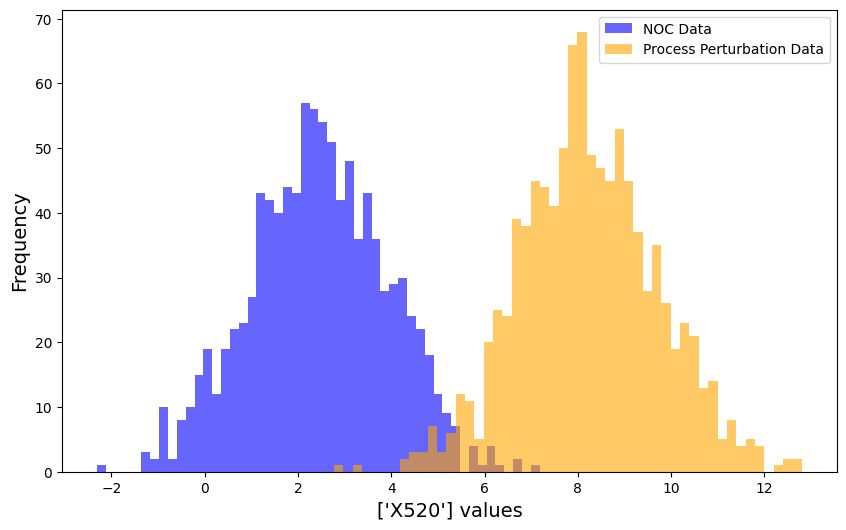

In [16]:
mean_noc , var_noc = noc_data[faulty_variable].mean(), noc_data[faulty_variable].std()
mean_proc, var_proc = data_process_perturbation[faulty_variable].mean(),data_process_perturbation[faulty_variable].std()
print(f'Mean and standard deviation of NOC Data: {(mean_noc,var_noc)}')
print(f'Mean and standard deviation of Process Perturbation Data: {(mean_proc,var_proc)}')
plt.figure(figsize=(10, 6))

plt.hist(noc_data[faulty_variable], bins=50, alpha=0.6, color='blue', label='NOC Data')
plt.hist(data_process_perturbation[faulty_variable], bins=50, alpha=0.6, color='orange', label='Process Perturbation Data')

plt.xlabel(f'{[faulty_variable]} values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.show()

### Examine a child of the faulty variable

Mean and standard deviation of NOC Data (child): (np.float64(-23.54594862931403), np.float64(18.09790553855348))
Mean and standard deviation of Process Perturbation Data (child): (np.float64(-11.746200259271657), np.float64(17.90963800214595))


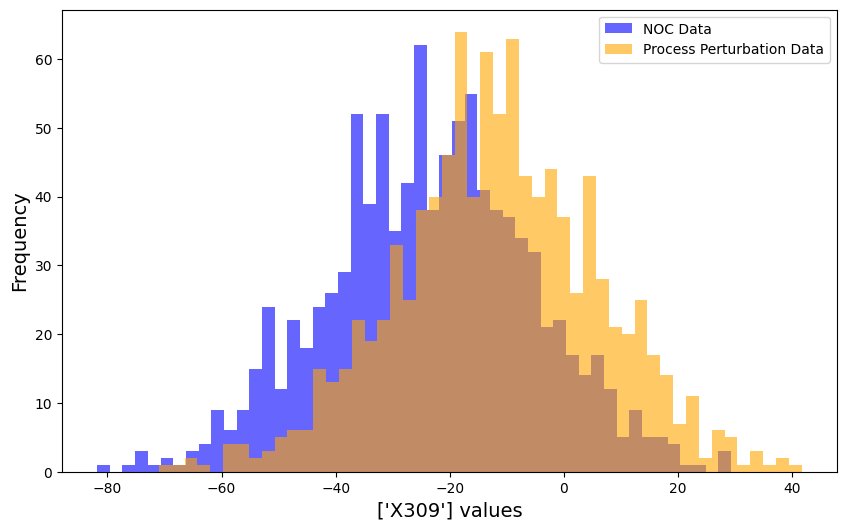

In [18]:
faulty_child = list(g.successors(faulty_variable))
mean_noc_c , var_noc_c = noc_data[faulty_child[0]].mean(), noc_data[faulty_child[0]].std()
mean_proc_c, var_proc_c = data_process_perturbation[faulty_child[0]].mean(),data_process_perturbation[faulty_child[0]].std()
print(f'Mean and standard deviation of NOC Data (child): {(mean_noc_c,var_noc_c)}')
print(f'Mean and standard deviation of Process Perturbation Data (child): {(mean_proc_c,var_proc_c)}')
plt.figure(figsize=(10, 6))

plt.hist(noc_data[faulty_child[0]], bins=50, alpha=0.6, color='blue', label='NOC Data')
plt.hist(data_process_perturbation[faulty_child[0]], bins=50, alpha=0.6, color='orange', label='Process Perturbation Data')

plt.xlabel(f'{[faulty_child[0]]} values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.show()

## 4.3. Sensor Bias
- A fault is introduced by adding a random bias component directly proportional to the standard deviation of the measurement noise.
- Baseline data model: $X_{\text{noisy}} = X_{\text{raw}} + e_{\text{noise}}$, where $e_{\text{noise}} \sim \mathcal{N}(0, \sigma_{\text{noise}}^2)$.
- Faulty data model (Sensor Bias):

$$X_{\text{faulty}} = X_{\text{raw}} + e_{\text{noise}} + e_{\text{bias}}$$

Where the sensor bias component is modeled as:
$$e_{\text{bias}} \sim \mathcal{N}\left(0, \sigma_{\text{bias}}^2\right)$$

And its standard deviation ($\sigma_{\text{bias}}$) corresponds exactly to the implementation in the code:
$$\sigma_{\text{bias}} = k \cdot \sigma_{\text{noise}}$$

**Where:**
- $X_{\text{raw}}$: The original simulated value of the variable (`values`).
- $e_{\text{noise}}$: The standard measurement noise based on the target SNR (`noise`).
- $\sigma_{\text{noise}}$: The standard deviation of the measurement noise (`noise_std`).
- $k$: The fault magnitude factor (`sensor_fault`).
- $\sigma_{\text{bias}}$: The standard deviation of the injected sensor fault (`sensor_var`).
- $e_{\text{bias}}$: The random sensor bias added to the faulty nodes (`sensor_bias`).

In [19]:
t11=time.time()
faulty_sensor= 'X57'
simple_data_s = simulator.generate_data(num_observations, g, params, nonrootcoefs, intercept)
data_sensor = simulator.add_measurement_noise(simple_data_s, nodes, snr_db=10,sensor_fault=5,faulty_nodes=[faulty_sensor])
t12=time.time()

print(f'Elapsed Time: {t12-t11}')
print(f'Header of Faulty Data:\n {data_sensor.head()}')

Elapsed Time: 0.2399139404296875
Header of Faulty Data:
              X1             X2             X3             X4            X5  \
0 -5.081645e+05  -26494.739461   83737.310307   69497.028775 -41982.124220   
1 -7.898470e+05   20418.701542  195816.941704  216804.897355 -17970.161653   
2  1.535983e+06  365128.850431 -353218.875665 -514603.194012 -66070.579045   
3  4.225538e+05  106710.992450 -128806.587769 -193832.502622 -21868.974284   
4 -8.856982e+05  -66162.174152  128662.475323  328971.815762   8174.674701   

              X6           X7             X8           X9           X10  ...  \
0  -96823.926243  1481.242281   21330.174424 -8430.083174  29955.743976  ...   
1  -64095.380317   385.059295   18263.428510  1650.844569  33304.122760  ...   
2  451019.160040  4771.593877  222556.527175  1252.873693 -60478.291006  ...   
3  300641.108980  1574.658123   37720.251178  -273.797068 -21745.126157  ...   
4 -207328.934242   -16.451640 -100882.376529  3709.851871  20479.133829  .

### Comparing with NOC data

Mean and standard deviation of NOC Data: (np.float64(307.5114406626199), np.float64(348.40716709886823))
Mean and standard deviation of Sensor Bias Data: (np.float64(290.35601821315475), np.float64(636.8384945482061))


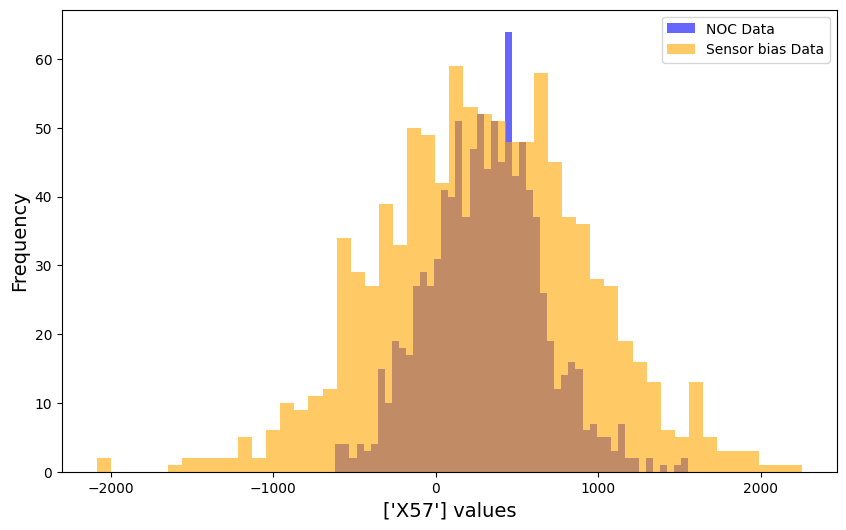

In [20]:
mean_noc_s , var_noc_s = noc_data[faulty_sensor].mean(), noc_data[faulty_sensor].std()
mean_sens, var_sens = data_sensor[faulty_sensor].mean(),data_sensor[faulty_sensor].std()
print(f'Mean and standard deviation of NOC Data: {(mean_noc_s,var_noc_s)}')
print(f'Mean and standard deviation of Sensor Bias Data: {(mean_sens,var_sens)}')
plt.figure(figsize=(10, 6))

plt.hist(noc_data[faulty_sensor], bins=50, alpha=0.6, color='blue', label='NOC Data')
plt.hist(data_sensor[faulty_sensor], bins=50, alpha=0.6, color='orange', label='Sensor bias Data')

plt.xlabel(f'{[faulty_sensor]} values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.show()

### Examining with the child of the faulty variable

Mean and standard deviation of NOC Data (child): (np.float64(3688.3195038089775), np.float64(937.3354619668683))
Mean and standard deviation of Process Perturbation Data (child): (np.float64(3649.034813844797), np.float64(1022.4533788077179))


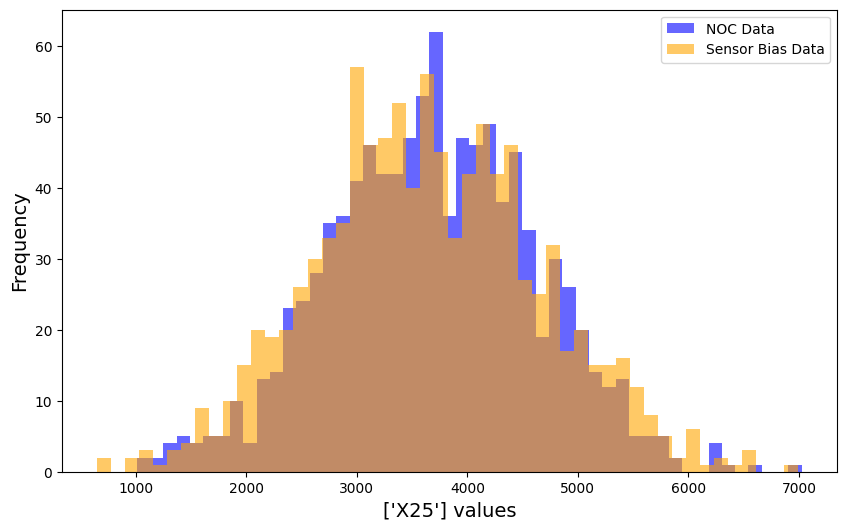

In [23]:
faulty_sens_child = list(g.successors(faulty_sensor))
mean_noc_cs , var_noc_cs = noc_data[faulty_sens_child[0]].mean(), noc_data[faulty_sens_child[0]].std()
mean_proc_cs, var_proc_cs = data_sensor[faulty_sens_child[0]].mean(),data_sensor[faulty_sens_child[0]].std()
print(f'Mean and standard deviation of NOC Data (child): {(mean_noc_cs,var_noc_cs)}')
print(f'Mean and standard deviation of Process Perturbation Data (child): {(mean_proc_cs,var_proc_cs)}')
plt.figure(figsize=(10, 6))

plt.hist(noc_data[faulty_sens_child[0]], bins=50, alpha=0.6, color='blue', label='NOC Data')
plt.hist(data_sensor[faulty_sens_child[0]], bins=50, alpha=0.6, color='orange', label='Sensor Bias Data')

plt.xlabel(f'{[faulty_sens_child[0]]} values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.show()

## 4.4. Correlation Change

- A fault is introduced by change the structural coefficient ($\beta_{ji}$) that links a parent node $j$ to its child node $i$.
- This simulates an modification in the causal mechanism between two variables.
- Modified Coefficient Model:

$$\beta_{ji}^{*} = \beta_{ji} \cdot \left(1 - \frac{k}{100}\right)$$

**Where:**
- $\beta_{ji}^{*}$: The modified causal coefficient used to generate the faulty data.
- $\beta_{ji}$: The original baseline coefficient sampled from the Student's t-distribution (`old_coef`).
- $k$: The percentage factor applied to the coefficient (`k` parameter, e.g., if $k=40$, the link's impact is reduced by 40%).
- The structural equation for the affected child node $X_i$ during the data generation becomes:
  $$X_i = \alpha_i + \dots + \beta_{ji}^{*} X_j + \dots + e_i$$

In [28]:
t13=time.time()
coef_mod = simulator.correlation_fault(nonrootcoefs,g,k=70,affect_edge=[('X737','X550')])
simple_data_c = simulator.generate_data(num_observations, g, params, coef_mod, intercept)
data_correlation = simulator.add_measurement_noise(simple_data_c,nodes, snr_db=10)
t14=time.time()

print(f'Elapsed Time: {t14-t13}')
print(f'Header of NOC Data:\n {data_correlation.head()}')

Elapsed Time: 0.22541260719299316
Header of NOC Data:
              X1             X2             X3             X4            X5  \
0  1.437331e+06  197652.209958 -232787.732504 -484217.520733 -54342.626302   
1 -3.250473e+05  -85866.238939  201924.856205  192197.223462  -9991.718964   
2  5.781838e+04   71680.355244  -20110.855489  -12784.420583 -45696.269257   
3  6.378785e+05  161822.000100 -156383.385063 -250732.252957 -40724.013605   
4  1.674433e+06  308915.999824 -362097.129864 -628423.680471 -62951.659429   

              X6           X7             X8           X9           X10  ...  \
0  487009.985632  2860.065772  171129.900209 -4593.663105 -42607.508126  ...   
1   -1419.811078   855.738451   -6400.841177   718.774258   7138.636426  ...   
2   37961.440070   963.142167   14967.759973 -2438.686917    996.085732  ...   
3  385493.984495  3243.701601  107676.432384  -687.506749 -47523.497145  ...   
4  455505.681412  3989.686770  202892.033798     5.948471 -94188.771552  ...

### Comparing with NOC data

Mean and standard deviation of NOC Data: (np.float64(-0.30298846616448866), np.float64(1.286660369006503))
Mean and standard deviation of Sensor Bias Data: (np.float64(0.6085841240476946), np.float64(1.0585986851226796))


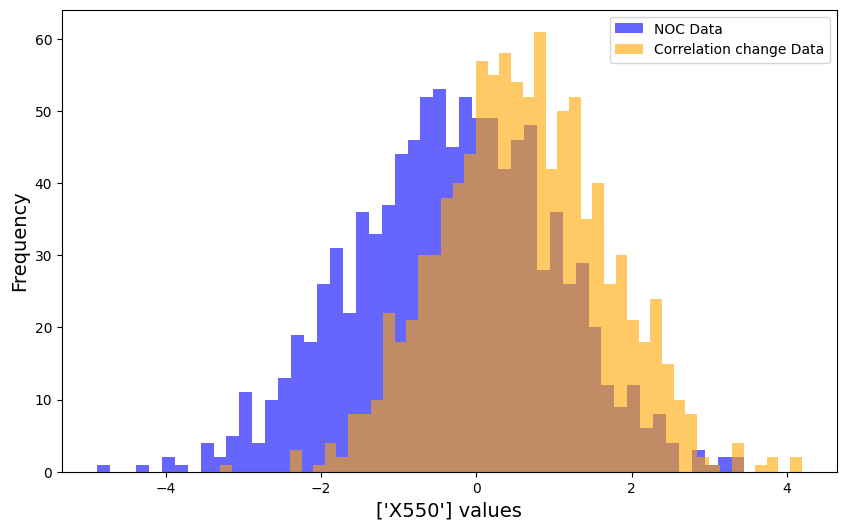

In [29]:
faulty_corr = 'X550'
mean_noc_cc , var_noc_cc = noc_data[faulty_corr].mean(), noc_data[faulty_corr].std()
mean_corr, var_corr = data_correlation[faulty_corr].mean(),data_correlation[faulty_corr].std()
print(f'Mean and standard deviation of NOC Data: {(mean_noc_cc,var_noc_cc)}')
print(f'Mean and standard deviation of Sensor Bias Data: {(mean_corr,var_corr)}')
plt.figure(figsize=(10, 6))

plt.hist(noc_data[faulty_corr], bins=50, alpha=0.6, color='blue', label='NOC Data')
plt.hist(data_correlation[faulty_corr], bins=50, alpha=0.6, color='orange', label='Correlation change Data')

plt.xlabel(f'{[faulty_corr]} values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.show()

## 4.5. Generate and Save NOC Datasets

- It generates and save data under **Normal Operating Conditions (NOC)** to serve as the baseline calibration and validation datasets for the study.



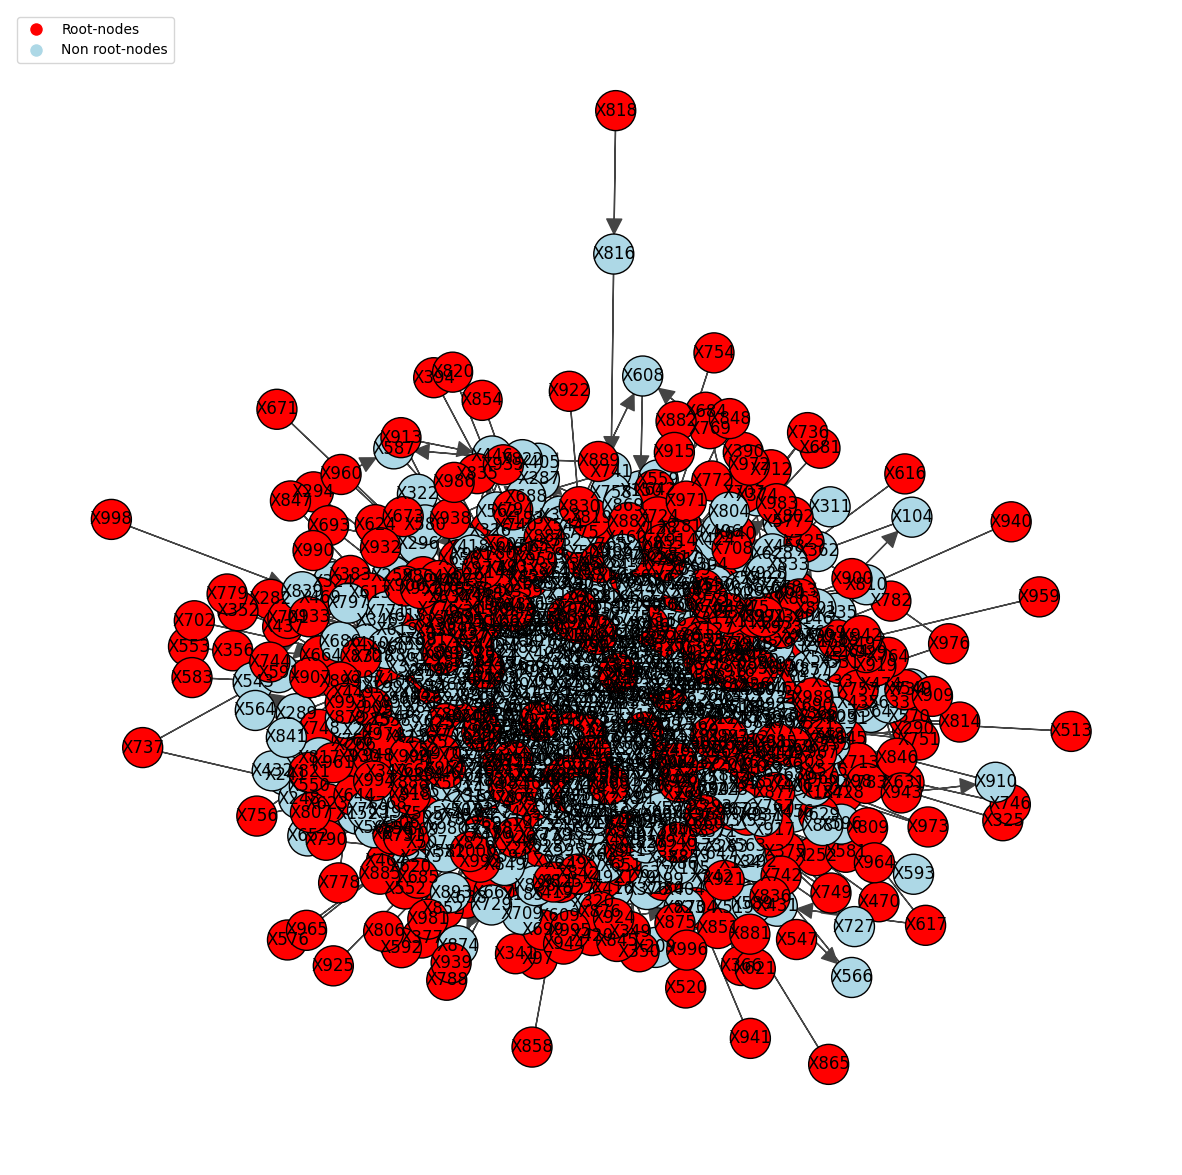

X1 = 0+(-0.50)*X2 + (-0.63)*X3 + (-2.92)*X4 + (-0.51)*X5 + (0.03)*X6 + (-0.31)*X8 + (0.16)*X9 + (0.34)*X10 + (-1.47)*X11 + (-1.28)*X12 + (1.09)*X15 + (-1.66)*X18 + (-1.86)*X20 + (-4.43)*X21 + (-0.64)*X28 + (0.63)*X29 + (0.16)*X41 + (0.09)*X42 + (-1.24)*X48 + (-4.84)*X53 + (0.79)*X54 + (0.19)*X64 + (-0.12)*X68 + (3.16)*X69 + (-1.36)*X95 + (0.38)*X99 + (-0.76)*X103 + (-0.29)*X106 + (-0.05)*X107 + (-0.74)*X116 + (-1.48)*X121 + (1.31)*X128 + (-1.15)*X141 + (-1.88)*X142 + (-0.29)*X159 + (0.93)*X162 + (-2.70)*X180 + (-0.56)*X182 + (-1.59)*X188 + (0.84)*X196 + (-0.02)*X205 + (0.82)*X210 + (-0.06)*X212 + (3.35)*X219 + (-1.61)*X229 + (-0.80)*X245 + (1.13)*X255 + (-0.05)*X260 + (-0.43)*X267 + (0.74)*X268 + (1.37)*X342 + (-0.93)*X369 + (0.31)*X382 + (0.50)*X395 + (0.43)*X406 + (1.06)*X407 + (1.99)*X414 + (-0.21)*X421 + (0.48)*X473 + (0.70)*X484 + (-2.07)*X501 + (0.17)*X537 + (-0.01)*X561 + (2.24)*X627 + (1.76)*X630 + (-1.11)*X670 + (-0.01)*X706 + (-3.46)*X771 + (0.81)*X815 + (3.20)*X817 + (-2.27)

In [30]:
filename = "test_1000obs.csv"
simulator.save_datasets_cal_val(g,nodes,filename,num_observations=1000)